# 16 · Bayesian optimization: choosing the next experiment

*You can only afford a handful of samples. Which settings do you actually make?*

> ⏱ **Runtime:** ~10 s on a laptop CPU (no GPU) · 🎓 **Level:** intermediate · 📊 **Data:** synthetic property landscape

### 🎯 What you'll learn
1. why **active learning** matters when every experiment is expensive,
2. how a **Gaussian-process surrogate** models a property *with uncertainty*,
3. how an **acquisition function** trades **exploration vs exploitation** to pick what to run next,
4. that **Bayesian optimization** finds the best setting in far fewer experiments than trial-and-error.

### 🧭 What you need to know first
- The idea of regression from notebooks **01a** and **12** (fit a curve to data).
- That predictions can come with an **uncertainty**, not just a value.
- Nothing about nanoindentation, this is a general materials-discovery method.

> 🧭 **The setup.** You are tuning one processing knob (say a normalised annealing temperature `x`)
> to maximise a property (call it hardness). Each experiment is slow and costly, so you cannot scan
> every value. **Bayesian optimization** builds a cheap model of the property, then uses it to decide
> the single most useful experiment to run next. We use a **synthetic** property so we can peek at the
> true answer and check how quickly the method gets there.

### Step 0: set-up

First things first: run the cell below with **Shift + Enter**.

> 🟢 **Colab users:** this cell also pulls the repo and installs a couple of extra packages, roughly a minute the first time. On a local install it finishes immediately.

> ✅ **You should see:** a line like `helpers loaded from: .../mecanano_ml/__init__.py`. That confirms the helper package loaded correctly.

In [1]:
# --- Setup cell — run me first! ---------------------------------------------
# It makes the helper package `mecanano_ml` importable and sets a clean plot
# style. You do not need to understand every line here; just run it.
# On Google Colab it also clones the repo and installs the few extra packages
# Colab doesn't ship (takes ~1 min, once per session).
import os, sys, subprocess

def _find_src():
    # Look for the repo's src/ folder in the usual places (local clone / Colab).
    for p in ("../src", "src", "mecanano-ml-nanomechanics/src"):
        if os.path.isdir(p):
            return p
    return None

if "google.colab" in sys.modules:             # running on Colab -> set everything up
    # packages Colab does not preinstall (torch/sklearn/etc. are already there):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "hdbscan", "umap-learn", "pyts", "shap", "imbalanced-learn"],
                   check=False)

if _find_src() is None:                       # bare session (e.g. Colab): fetch the repo
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/edrossi93/mecanano-ml-nanomechanics.git"],
                   check=False)

sys.path.insert(0, os.path.abspath(_find_src() or "mecanano-ml-nanomechanics/src"))

import numpy as np                 # arrays and maths
import pandas as pd                # tables (each row = one indent)
import matplotlib.pyplot as plt    # plotting
import mecanano_ml as mm           # our tiny helper package: loaders + plotting
mm.set_style()                     # consistent, publication-like figures
# Confirm the helpers loaded (just the tail of the path, not your machine's folders).
_pkg = os.path.basename(os.path.dirname(mm.__file__))
print("helpers loaded from: .../" + _pkg + "/" + os.path.basename(mm.__file__))

helpers loaded from: .../mecanano_ml/__init__.py


In [2]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel, WhiteKernel
rng = np.random.default_rng(0)

## 1 · One expensive property to maximise

The property depends on the setting `x` in some unknown way, with a **global best** and a **decoy**
local peak that could fool a greedy search. In real life you never see this curve; each measurement
is one experiment.

> 🧠 **objective**: the quantity you want to maximise (here a property vs the setting `x`). Each evaluation is one costly experiment.

> ✅ **Expect:** the hidden property landscape: a tall peak near `x = 0.72` and a shorter decoy near `x = 0.25`. Bayesian optimization does **not** get to see this.

(hidden) best setting x* = 0.72,  best property = 1.39


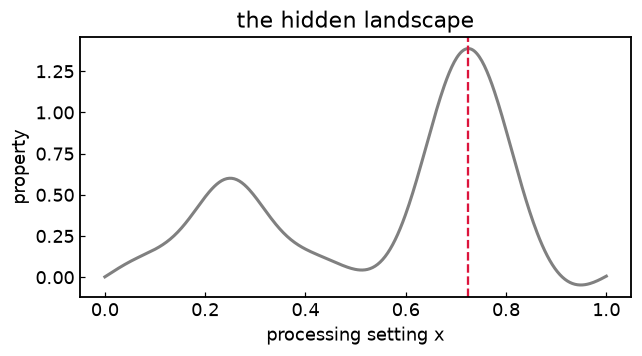

In [3]:
def landscape(x):                                    # the TRUE property (unknown in practice)
    return (1.3 * np.exp(-((x - 0.72) / 0.12) ** 2)  # global peak
            + 0.7 * np.exp(-((x - 0.25) / 0.10) ** 2)  # decoy local peak
            + 0.10 * np.sin(6 * np.pi * x))            # gentle wiggle

def measure(x, r):                                   # one experiment = truth + measurement noise
    return landscape(x) + r.normal(0, 0.03, np.shape(x))

grid = np.linspace(0, 1, 400)                        # dense grid, only for plotting / picking
truth = landscape(grid); x_star = grid[np.argmax(truth)]
print(f"(hidden) best setting x* = {x_star:.2f},  best property = {truth.max():.2f}")

fig, ax = plt.subplots(figsize=(6, 3.4))
ax.plot(grid, truth, "grey", lw=2); ax.axvline(x_star, ls="--", c="crimson")
ax.set_xlabel("processing setting x"); ax.set_ylabel("property"); ax.set_title("the hidden landscape")
fig.tight_layout()

*🖼 **Figure.** The prize is the tall peak near 0.72. A method that jumps on the first good result it sees could get stuck on the decoy near 0.25.*

## 2 · A surrogate you *can* afford

Fit a **Gaussian process** to the few experiments done so far. It predicts the property everywhere,
and crucially it says **how unsure it is**: confident near data, uncertain far from it.

> 🧠 **surrogate**: a cheap stand-in model of the expensive property, fit to the data collected so far and queried instead of running experiments.

> 🧠 **Gaussian process (GP)**: a regressor that returns a mean prediction **and** an uncertainty band, wide where it has no data.

> ✅ **Expect:** three random experiments, the GP mean through them, and a shaded **±2σ band** that balloons wherever we have not measured yet.

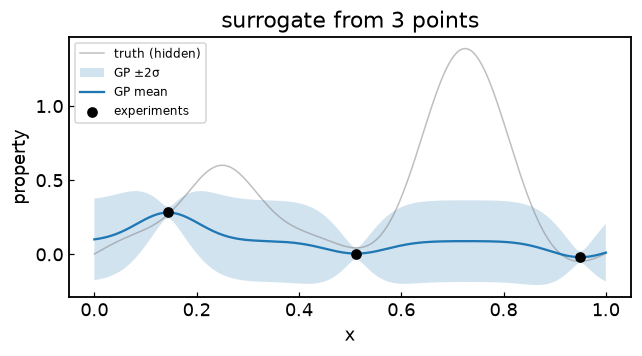

In [4]:
kernel = ConstantKernel(1.0) * RBF(0.1) + WhiteKernel(0.01)   # smoothness + a little noise
def fit_gp(X, Y):
    return GaussianProcessRegressor(kernel=kernel, normalize_y=True,
                                    n_restarts_optimizer=2, random_state=0).fit(np.array(X)[:, None], np.array(Y))

r = np.random.default_rng(1)
X = list(r.uniform(0, 1, 3)); Y = [float(measure(x, r)) for x in X]   # 3 initial experiments
gp = fit_gp(X, Y)
mu, sd = gp.predict(grid[:, None], return_std=True)

fig, ax = plt.subplots(figsize=(6, 3.4))
ax.plot(grid, truth, "grey", lw=1, alpha=.5, label="truth (hidden)")
ax.fill_between(grid, mu - 2 * sd, mu + 2 * sd, alpha=.2, label="GP ±2σ")
ax.plot(grid, mu, "C0", label="GP mean"); ax.scatter(X, Y, c="k", zorder=5, label="experiments")
ax.legend(fontsize=8); ax.set_xlabel("x"); ax.set_ylabel("property"); ax.set_title("surrogate from 3 points")
fig.tight_layout()

*🖼 **Figure.** The band is the whole point: the GP knows where it is guessing. That is what lets us choose the next experiment intelligently instead of at random.*

## 3 · Where to look next: the acquisition function

Turn "predicted value" and "uncertainty" into one score. The **upper confidence bound** adds them:
`UCB = mean + κ·σ`. A high mean rewards **exploitation**; a high σ rewards **exploration**. Its peak
is the next experiment.

> 🧠 **acquisition function**: a score over settings that says how useful each next experiment would be. We use **UCB = mean + κ·σ**.

> 🧠 **exploration vs exploitation**: trying uncertain regions that might hide the optimum, versus refining the best-known region. UCB's κ tunes the balance.

> ✅ **Expect:** the UCB curve peaking somewhere the GP is either high or very unsure, and a marker at the chosen next setting.

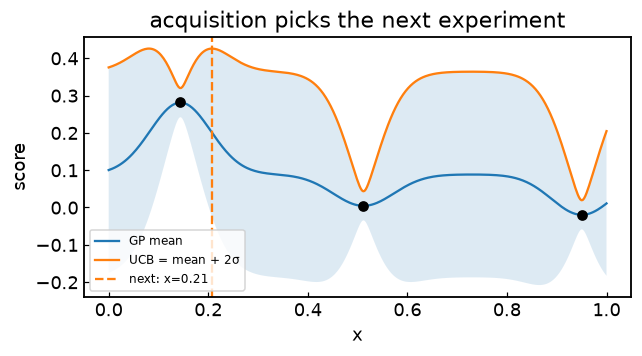

In [5]:
kappa = 2.0
ucb = mu + kappa * sd                                 # upper confidence bound
x_next = grid[np.argmax(ucb)]                         # the most promising setting to try next

fig, ax = plt.subplots(figsize=(6, 3.4))
ax.plot(grid, mu, "C0", label="GP mean"); ax.fill_between(grid, mu - 2 * sd, mu + 2 * sd, alpha=.15)
ax.plot(grid, ucb, "C1", label="UCB = mean + 2σ"); ax.scatter(X, Y, c="k", zorder=5)
ax.axvline(x_next, ls="--", c="C1", label=f"next: x={x_next:.2f}")
ax.legend(fontsize=8); ax.set_xlabel("x"); ax.set_ylabel("score"); ax.set_title("acquisition picks the next experiment")
fig.tight_layout()

*🖼 **Figure.** We do not just chase the current best guess; the σ term pulls us toward unexplored settings, which is how the method escapes the decoy peak.*

## 4 · The loop, and does it beat guessing?

Repeat: fit the GP, pick the UCB peak, run that experiment, add it, refit. A dozen rounds is plenty
here. Then compare against **random** sampling on the same budget.

> ✅ **Expect:** snapshots of the surrogate sharpening around the true peak, then a convergence curve where **Bayesian optimization reaches the top well before random search**.

BO best: 1.38 at x=0.72  (true best 1.39 at x*=0.72)
after 8 experiments  —  BO: 1.35   random: 1.05


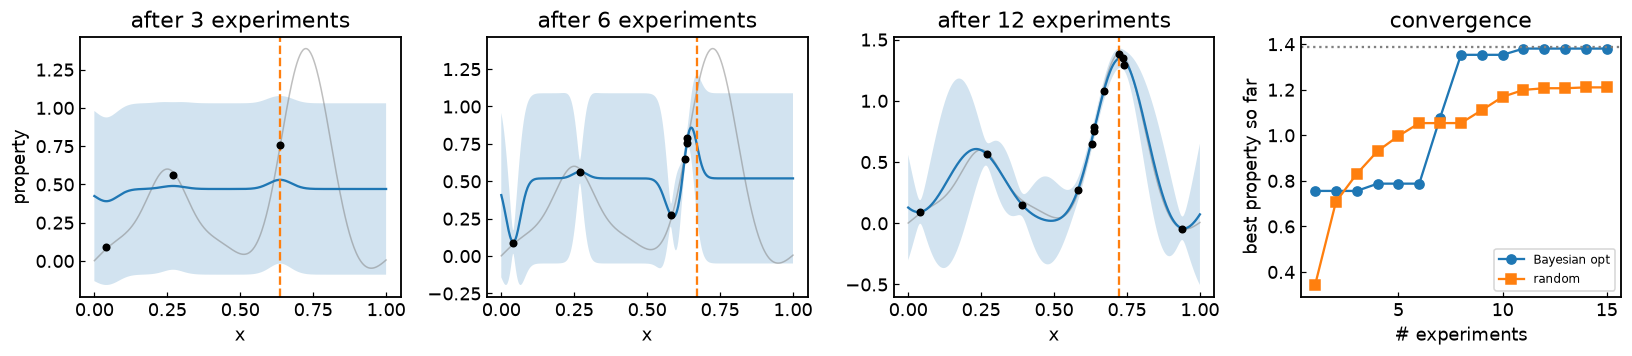

In [6]:
def run_bo(n_iter=12, seed=0):
    r = np.random.default_rng(seed)
    X = list(r.uniform(0, 1, 3)); Y = [float(measure(x, r)) for x in X]
    snaps = {}
    for t in range(n_iter):
        gp = fit_gp(X, Y); mu, sd = gp.predict(grid[:, None], return_std=True)
        xn = grid[np.argmax(mu + kappa * sd)]                 # UCB pick
        if t in (0, 3, 9): snaps[t] = (list(X), list(Y), mu, sd, xn)
        X.append(float(xn)); Y.append(float(measure(xn, r)))  # run the chosen experiment
    return np.array(X), np.array(Y), snaps

Xb, Yb, snaps = run_bo()
best_bo = np.maximum.accumulate(Yb)                            # best property found so far
best_rand = np.mean([np.maximum.accumulate(
    [float(measure(x, np.random.default_rng(200 + s))) for x in np.random.default_rng(200 + s).uniform(0, 1, len(Xb))])
    for s in range(25)], axis=0)                              # random search, averaged over seeds

fig, ax = plt.subplots(1, 4, figsize=(15, 3.4))
for a, t in zip(ax[:3], (0, 3, 9)):
    Xs, Ys, mu, sd, xn = snaps[t]
    a.plot(grid, truth, "grey", lw=1, alpha=.5); a.fill_between(grid, mu - 2 * sd, mu + 2 * sd, alpha=.2)
    a.plot(grid, mu, "C0"); a.scatter(Xs, Ys, c="k", s=18, zorder=5); a.axvline(xn, ls="--", c="C1")
    a.set_title(f"after {t + 3} experiments"); a.set_xlabel("x")
ax[0].set_ylabel("property")
ax[3].plot(np.arange(1, len(best_bo) + 1), best_bo, "o-", label="Bayesian opt")
ax[3].plot(np.arange(1, len(best_rand) + 1), best_rand, "s-", label="random")
ax[3].axhline(truth.max(), ls=":", c="grey"); ax[3].legend(fontsize=8)
ax[3].set_xlabel("# experiments"); ax[3].set_ylabel("best property so far"); ax[3].set_title("convergence")
fig.tight_layout()
print(f"BO best: {Yb.max():.2f} at x={Xb[np.argmax(Yb)]:.2f}  (true best {truth.max():.2f} at x*={x_star:.2f})")
print(f"after 8 experiments  —  BO: {best_bo[7]:.2f}   random: {best_rand[7]:.2f}")

*🖼 **Figure.** The surrogate locks onto the real peak within a few rounds, and the best-so-far curve for Bayesian optimization climbs faster than random search.*

### ✅ Self-check
Before moving on, confirm the numbers above make sense. The cell below raises an `AssertionError` if a later change sends a result off the rails.

In [7]:
# Each line fails loudly if a key result drifts out of a sensible range.
# (These also run in CI, so a broken result fails the build.)
assert abs(Xb[np.argmax(Yb)] - x_star) < 0.12, "BO should locate the true optimum, not the decoy"
assert Yb.max() > 0.9 * truth.max(), "BO should reach near the true maximum"
assert best_bo[7] > best_rand[7], "at 8 experiments BO should be ahead of random search"
print("self-check passed ✓ — found the optimum in few experiments")

self-check passed ✓ — found the optimum in few experiments


## ✅ Recap
- When experiments are expensive, spend them wisely: a **surrogate** (Gaussian process) models the property with **uncertainty** from just a few points.
- An **acquisition function** (UCB = mean + κ·σ) turns that into a single next experiment, balancing **exploration** and **exploitation**.
- The **Bayesian-optimization** loop reaches the true optimum in far fewer experiments than random or grid search, the reason it drives modern materials discovery.

## 🔧 Try it yourself
The best way to learn is to change one thing at a time:
1. Raise `kappa` to 5 (more exploration) then drop it to 0.3 (pure greed). Which gets stuck on the decoy?
2. Start from 1 initial point instead of 3. Does BO still find the global peak?
3. Replace UCB with a simple **probability of improvement** (score = P(property > best so far)). Does it converge slower?

## 🩹 Common errors & fixes
- **The GP band never shrinks** usually means the `WhiteKernel` noise is set far too high; lower it.
- **BO stalls on the decoy** means too little exploration; raise `kappa` or the RBF length scale.
- **`ConvergenceWarning` from the GP fit** is harmless here (the kernel optimiser hit its iteration cap).

---
**Next:** Swap `landscape()` for your own measured property (even a 2-D one), or revisit **`12_regression_curvefitting.ipynb`** for fitting when you *can* afford lots of data.